# OrganoidEnv — Multi-Seed Training on Google Colab

Runs the full multi-seed training + ablation pipeline for **OrganoidEnv**.

**Click Runtime → Run All.**

In [1]:
# 1. Clean installation of dependencies (NumPy 2.x + Brian2 >= 2.8 compatible)
import sys
print(f'Python version: {sys.version}')

# Uninstall stale packages that might hold older incompatible Brian2 versions
!pip uninstall -y -q brian2genn brian2
!pip install -q --upgrade pip
!pip install -q "brian2>=2.8.0" "numpy>=2.0.0" gymnasium torch matplotlib pandas scipy

Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.5 MB/s eta 0:00:0000:010:01


In [2]:
# 2. Clone the repository and install
import os
if os.path.exists('/content/Organoid-Intelligence-gym-'):
    %cd /content/Organoid-Intelligence-gym-
    !git pull
else:
    %cd /content
    !git clone https://github.com/vansh7nvc/Organoid-Intelligence-gym-.git
    %cd Organoid-Intelligence-gym-
!pip install -q -e .

/content
Cloning into 'Organoid-Intelligence-gym-'...
remote: Enumerating objects: 747, done.
remote: Counting objects: 100% (747/747), done.
remote: Compressing objects: 100% (338/338), done.
remote: Total 747 (delta 440), reused 696 (delta 392), pack-reused 0 (from 0)
Receiving objects: 100% (747/747), 18.67 MiB | 29.10 MiB/s, done.
Resolving deltas: 100% (440/440), done.
/content/Organoid-Intelligence-gym-
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for organoid_rl (pyproject.toml) ... done


In [3]:
# 3. Verify Setup
import numpy as np
import brian2 as b2
import torch
import gymnasium

print(f'NumPy version:      {np.__version__}')
print(f'Brian2 version:     {b2.__version__}')
print(f'Brian2 backend:     {b2.prefs.codegen.target}')
print(f'PyTorch version:    {torch.__version__}')
print(f'CUDA available:     {torch.cuda.is_available()}')
print(f'Gymnasium version:  {gymnasium.__version__}')
print('\n✅ All imports OK!')

NumPy version:      2.1.3
Brian2 version:     2.10.1
Brian2 backend:     auto
PyTorch version:    2.11.0+cpu
CUDA available:     False
Gymnasium version:  1.3.0

✅ All imports OK!


In [5]:
# 4. Quick Smoke Test (5 simulation steps)
import sys
sys.path.insert(0, '.')
from organoid_rl.environment.core import OrganoidEnv
from organoid_rl.agents.dqn_agent import DQNAgent

env = OrganoidEnv()
agent = DQNAgent(obs_dim=21, n_actions=8)
state, info = env.reset()
for step in range(5):
    action = agent.choose_action(state)
    state, reward, term, trunc, info = env.step(action)
    agent.store_transition(state, action, reward, state, term or trunc)
    if term or trunc:
        break
print(f'Smoke test passed: state.shape={state.shape}, reward={reward:.2f}')
print('✅ Environment + Agent working!')

KeyboardInterrupt: 

In [6]:
# 5. Mount Google Drive (for checkpoint persistence)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('✅ Google Drive mounted.')
except:
    print('⚠️ Drive not available. Results saved locally.')

Mounted at /content/drive
✅ Google Drive mounted.


In [14]:
# 6. Run Multi-Seed Training (3 seeds × 200 episodes)
# Checkpoints saved every 25 episodes to Google Drive.
# If disconnected, simply re-run this cell to resume automatically.
!PYTHONPATH="." python organoid_rl/experiments/publication/20_colab_multiseed_v2.py

Running in Google Colab.
Colab Multi-seed V2. Saving to /content/drive/MyDrive/OrganoidEnv_Results/multiseed_v2

Starting Training for Seed 42
Resuming seed 42 from episode 6
Seed 42 | Ep   6/200 | Stage 1 | Reward:   53.8 | Success: 1 | Loss: 0.0000 | Time: 70.5s
Seed 42 | Ep   7/200 | Stage 1 | Reward:   64.4 | Success: 1 | Loss: 0.0000 | Time: 9.3s
Seed 42 | Ep   8/200 | Stage 1 | Reward:   64.9 | Success: 1 | Loss: 0.0000 | Time: 11.0s
Seed 42 | Ep   9/200 | Stage 1 | Reward:   54.5 | Success: 1 | Loss: 0.0000 | Time: 5.3s
Seed 42 | Ep  10/200 | Stage 1 | Reward:   64.8 | Success: 1 | Loss: 0.0000 | Time: 9.7s
Seed 42 | Ep  11/200 | Stage 1 | Reward:   61.6 | Success: 1 | Loss: 0.0000 | Time: 8.2s
Seed 42 | Ep  12/200 | Stage 1 | Reward:   53.0 | Success: 1 | Loss: 0.0000 | Time: 4.7s
Seed 42 | Ep  13/200 | Stage 1 | Reward:   61.2 | Success: 1 | Loss: 15.5219 | Time: 9.6s
Seed 42 | Ep  14/200 | Stage 1 | Reward:   62.1 | Success: 1 | Loss: 17.1877 | Time: 9.1s
Seed 42 | Ep  15/200

In [7]:
%cd /content/Organoid-Intelligence-gym-
!PYTHONPATH="." python organoid_rl/experiments/publication/21_colab_ablations_v2.py


/content/Organoid-Intelligence-gym-
Running in Google Colab.
Colab Ablation Runner V2. Saving to /content/drive/MyDrive/OrganoidEnv_Results/ablations_v2

Starting Training for No_GAR_seed_42
Resuming No_GAR_seed_42 from episode 100
Loaded saved agent weights.
Run No_GAR_seed_42 already completed 100 episodes. Skipping.
WARNING    The object 'synapses_4' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/content/Organoid-Intelligence-gym-/organoid_rl/environment/core.py', line 163, in create_syn
    S = Synapses(pre, post, model=syn_eqs, on_pre=op, method='euler', namespace=ns) [brian2.core.base.unused_brian_object]
WARNING    The object 'synapses_3' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable,

In [8]:
# 8. Plot Results
import pandas as pd
import matplotlib.pyplot as plt
import glob

res_dir = 'organoid_rl/experiments/publication/colab_results_v2'

# --- Multi-seed learning curves ---
seed_files = sorted(glob.glob(f'{res_dir}/training_log_seed_*.csv'))
if seed_files:
    fig, ax = plt.subplots(figsize=(10, 5))
    for f in seed_files:
        df = pd.read_csv(f)
        seed_val = int(df['seed'].iloc[0])
        ax.plot(df['episode'], df['reward'].rolling(10).mean(), alpha=0.6, label=f'Seed {seed_val}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward (10-ep rolling avg)')
    ax.set_title('OrganoidEnv: Multi-Seed Training')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{res_dir}/multiseed_learning_curve.png', dpi=150)
    plt.show()
else:
    print('No multi-seed results found yet.')

# --- Ablation comparison ---
abl_files = sorted(glob.glob(f'{res_dir}/training_log_*_seed_*.csv'))
if abl_files:
    fig, ax = plt.subplots(figsize=(10, 5))
    all_abl = pd.concat([pd.read_csv(f) for f in abl_files])
    for name, grp in all_abl.groupby('ablation'):
        mean = grp.groupby('episode')['reward'].mean()
        ax.plot(mean.index, mean.rolling(10).mean(), label=name)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward (10-ep rolling avg)')
    ax.set_title('Ablation Study')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{res_dir}/ablation_comparison.png', dpi=150)
    plt.show()
else:
    print('No ablation results found yet.')

print('\n✅ Done! Plots saved to:', res_dir)

No multi-seed results found yet.
No ablation results found yet.

✅ Done! Plots saved to: organoid_rl/experiments/publication/colab_results_v2


Loading results from: /content/drive/MyDrive/OrganoidEnv_Results/multiseed_v2


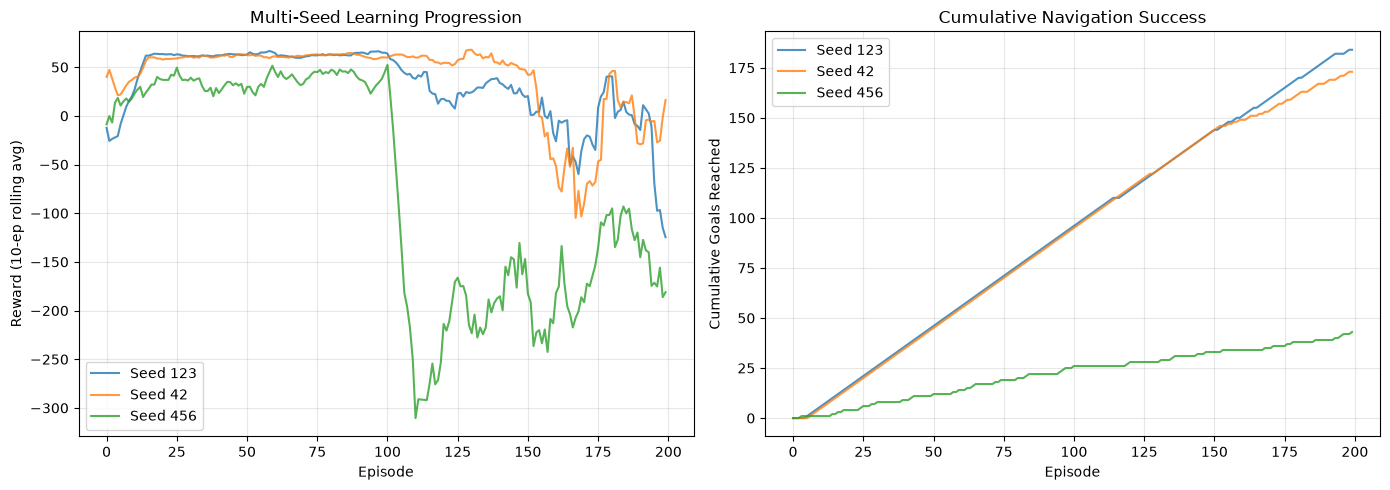

Plot saved to: /content/drive/MyDrive/OrganoidEnv_Results/multiseed_v2/multiseed_summary_plot.png


In [16]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd

# Check both Google Drive and local paths
possible_dirs = [
    "/content/drive/MyDrive/OrganoidEnv_Results/multiseed_v2",
    "/content/colab_results_v2",
    "organoid_rl/experiments/publication/colab_results_v2",
]

res_dir = None
for d in possible_dirs:
  if os.path.exists(d) and len(glob.glob(f"{d}/training_log_seed_*.csv")) > 0:
    res_dir = d
    break

print(f"Loading results from: {res_dir}")

if res_dir:
  seed_files = sorted(glob.glob(f"{res_dir}/training_log_seed_*.csv"))
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

  # 1. Reward Curve
  for f in seed_files:
    df = pd.read_csv(f)
    seed_val = int(df["seed"].iloc[0])
    ax1.plot(
        df["episode"],
        df["reward"].rolling(10, min_periods=1).mean(),
        alpha=0.8,
        label=f"Seed {seed_val}",
    )
  ax1.set_xlabel("Episode")
  ax1.set_ylabel("Reward (10-ep rolling avg)")
  ax1.set_title("Multi-Seed Learning Progression")
  ax1.legend()
  ax1.grid(True, alpha=0.3)

  # 2. Cumulative Success Rate
  for f in seed_files:
    df = pd.read_csv(f)
    seed_val = int(df["seed"].iloc[0])
    if "cumulative_goals" in df.columns:
      ax2.plot(
          df["episode"],
          df["cumulative_goals"],
          alpha=0.8,
          label=f"Seed {seed_val}",
      )
  ax2.set_xlabel("Episode")
  ax2.set_ylabel("Cumulative Goals Reached")
  ax2.set_title("Cumulative Navigation Success")
  ax2.legend()
  ax2.grid(True, alpha=0.3)

  plt.tight_layout()
  plt.savefig(f"{res_dir}/multiseed_summary_plot.png", dpi=150)
  plt.show()
  print(f"Plot saved to: {res_dir}/multiseed_summary_plot.png")
else:
  print("❌ No seed files found. Please check your Google Drive directory.")


Found 3 multi-seed log files.
Found 6 ablation log files.


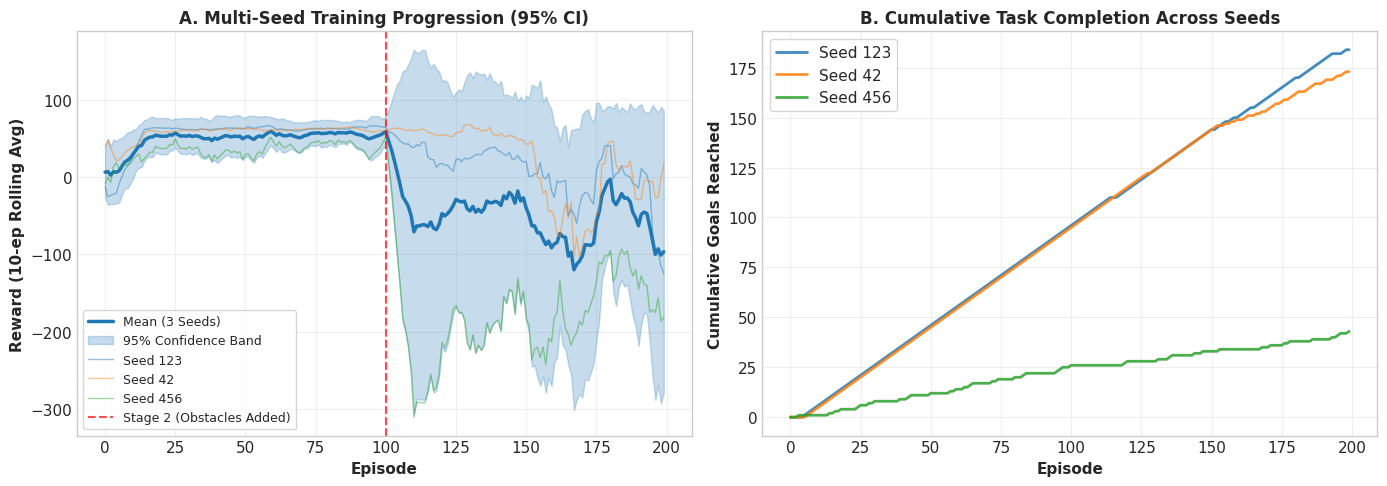

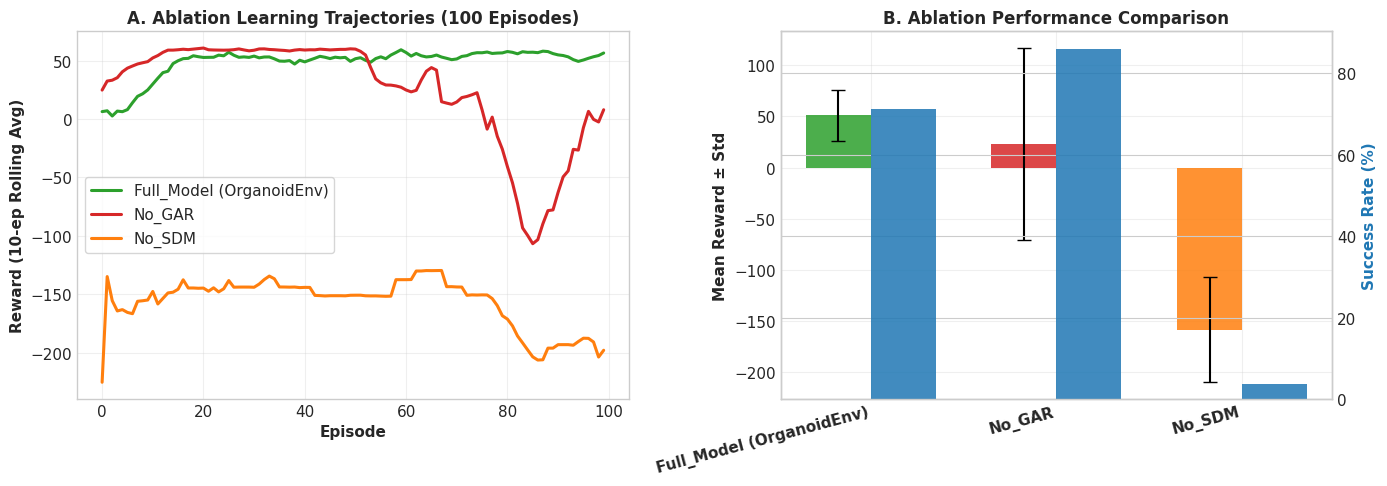


  STATISTICAL SUMMARY FOR LATEX MANUSCRIPT
Stage 1 (Basic Nav) Success Rate: 71.3% ± 40.1%
Stage 2 (Obstacles) Success Rate: 62.0% ± 38.4%
Overall Multi-Seed Success Rate:  66.7% ± 39.2%

Ablation Comparisons (First 100 Episodes):
  - Full_Model (OrganoidEnv)  : Mean Reward =  51.00 ± 24.89 | Success =  71.3%
  - No_GAR                    : Mean Reward =  23.14 ± 93.70 | Success =  86.0%
  - No_SDM                    : Mean Reward = -158.31 ± 51.28 | Success =   3.7%

Saved all figures and data to /content/OrganoidEnv_Results.zip
Triggering browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import glob
import json
import os
import shutil
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set publication plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

# Paths
multiseed_dir = '/content/drive/MyDrive/OrganoidEnv_Results/multiseed_v2'
ablation_dir = '/content/drive/MyDrive/OrganoidEnv_Results/ablations_v2'
output_dir = '/content/publication_figures'
os.makedirs(output_dir, exist_ok=True)

# 1. LOAD MULTI-SEED DATA
seed_files = sorted(glob.glob(f'{multiseed_dir}/training_log_seed_*.csv'))
print(f'Found {len(seed_files)} multi-seed log files.')
multi_dfs = [pd.read_csv(f) for f in seed_files]
df_multi = pd.concat(multi_dfs, ignore_index=True)

# 2. LOAD ABLATION DATA
abl_files = sorted(glob.glob(f'{ablation_dir}/training_log_*_seed_*.csv'))
print(f'Found {len(abl_files)} ablation log files.')
abl_dfs = [pd.read_csv(f) for f in abl_files]
df_abl = pd.concat(abl_dfs, ignore_index=True) if abl_dfs else pd.DataFrame()

# ==============================================================================
# FIGURE 1: MULTI-SEED LEARNING PROGRESSION WITH 95% CONFIDENCE INTERVAL
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Group by episode across seeds
grouped = df_multi.groupby('episode')
mean_reward = grouped['reward'].mean()
std_reward = grouped['reward'].std().fillna(0)
rolling_mean = mean_reward.rolling(10, min_periods=1).mean()
rolling_std = std_reward.rolling(10, min_periods=1).mean()

# Left Plot: Reward Mean + 95% CI band
ax1.plot(
    mean_reward.index,
    rolling_mean,
    color='#1f77b4',
    lw=2.5,
    label='Mean (3 Seeds)',
)
ax1.fill_between(
    mean_reward.index,
    rolling_mean - 1.96 * rolling_std / np.sqrt(len(seed_files)),
    rolling_mean + 1.96 * rolling_std / np.sqrt(len(seed_files)),
    color='#1f77b4',
    alpha=0.25,
    label='95% Confidence Band',
)

# Plot individual seeds lightly
for f in seed_files:
  s_df = pd.read_csv(f)
  s_num = int(s_df['seed'].iloc[0])
  ax1.plot(
      s_df['episode'],
      s_df['reward'].rolling(10, min_periods=1).mean(),
      lw=1,
      alpha=0.45,
      label=f'Seed {s_num}',
  )

ax1.axvline(
    x=100,
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Stage 2 (Obstacles Added)',
)
ax1.set_xlabel('Episode', fontweight='bold')
ax1.set_ylabel('Reward (10-ep Rolling Avg)', fontweight='bold')
ax1.set_title(
    'A. Multi-Seed Training Progression (95% CI)',
    fontweight='bold',
    fontsize=12,
)
ax1.legend(loc='lower left', frameon=True, fontsize=9)
ax1.grid(True, alpha=0.3)

# Right Plot: Cumulative Goals Reached
for f in seed_files:
  s_df = pd.read_csv(f)
  s_num = int(s_df['seed'].iloc[0])
  ax2.plot(
      s_df['episode'],
      s_df['cumulative_goals'],
      lw=2,
      alpha=0.85,
      label=f'Seed {s_num}',
  )

ax2.set_xlabel('Episode', fontweight='bold')
ax2.set_ylabel('Cumulative Goals Reached', fontweight='bold')
ax2.set_title(
    'B. Cumulative Task Completion Across Seeds',
    fontweight='bold',
    fontsize=12,
)
ax2.legend(loc='upper left', frameon=True)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig1_path = f'{output_dir}/fig1_multiseed_progression.png'
plt.savefig(fig1_path, dpi=300)
plt.show()

# ==============================================================================
# FIGURE 2: ABLATION BENCHMARK COMPARISON
# ==============================================================================
if not df_abl.empty:
  fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

  # Add Full Model (first 100 episodes from multi-seed) for direct comparison
  df_full_100 = df_multi[df_multi['episode'] < 100].copy()
  df_full_100['ablation'] = 'Full_Model (OrganoidEnv)'

  combined_abl = pd.concat([df_full_100, df_abl], ignore_index=True)

  # Color palette
  palette = {
      'Full_Model (OrganoidEnv)': '#2ca02c',
      'No_GAR': '#d62728',
      'No_SDM': '#ff7f0e',
  }

  # Trajectory Plot
  for name, grp in combined_abl.groupby('ablation'):
    ep_mean = grp.groupby('episode')['reward'].mean()
    roll_m = ep_mean.rolling(10, min_periods=1).mean()
    color = palette.get(name, '#333333')
    ax3.plot(roll_m.index, roll_m, lw=2.2, color=color, label=name)

  ax3.set_xlabel('Episode', fontweight='bold')
  ax3.set_ylabel('Reward (10-ep Rolling Avg)', fontweight='bold')
  ax3.set_title(
      'A. Ablation Learning Trajectories (100 Episodes)',
      fontweight='bold',
      fontsize=12,
  )
  ax3.legend(frameon=True)
  ax3.grid(True, alpha=0.3)

  # Summary Bar Chart: Mean Reward & Success Rate
  summary = combined_abl.groupby('ablation').agg(
      {'reward': ['mean', 'std'], 'success': ['mean']}
  )
  ab_names = summary.index.tolist()
  means = summary['reward']['mean'].values
  stds = summary['reward']['std'].values
  success_rates = summary['success']['mean'].values * 100

  x = np.arange(len(ab_names))
  width = 0.35

  bars1 = ax4.bar(
      x - width / 2,
      means,
      width,
      yerr=stds,
      capsize=5,
      label='Mean Reward',
      color=['#2ca02c', '#d62728', '#ff7f0e'],
      alpha=0.85,
  )
  ax4_twin = ax4.twinx()
  bars2 = ax4_twin.bar(
      x + width / 2,
      success_rates,
      width,
      label='Success Rate (%)',
      color='#1f77b4',
      alpha=0.85,
  )

  ax4.set_xticks(x)
  ax4.set_xticklabels(ab_names, rotation=15, ha='right', fontweight='bold')
  ax4.set_ylabel('Mean Reward ± Std', fontweight='bold')
  ax4_twin.set_ylabel('Success Rate (%)', fontweight='bold', color='#1f77b4')
  ax4.set_title(
      'B. Ablation Performance Comparison', fontweight='bold', fontsize=12
  )
  ax4.grid(True, alpha=0.3)

  plt.tight_layout()
  fig2_path = f'{output_dir}/fig2_ablation_comparison.png'
  plt.savefig(fig2_path, dpi=300)
  plt.show()

# ==============================================================================
# 3. PRINT STATISTICAL SUMMARY FOR LATEX MANUSCRIPT
# ==============================================================================
print('\n' + '=' * 70)
print('  STATISTICAL SUMMARY FOR LATEX MANUSCRIPT')
print('=' * 70)

# Stage 1 (Ep 0-100) vs Stage 2 (Ep 100-200)
st1 = df_multi[df_multi['episode'] < 100]
st2 = df_multi[df_multi['episode'] >= 100]

print(
    f"Stage 1 (Basic Nav) Success Rate: {st1['success'].mean()*100:.1f}% ±"
    f" {st1.groupby('seed')['success'].mean().std()*100:.1f}%"
)
print(
    f"Stage 2 (Obstacles) Success Rate: {st2['success'].mean()*100:.1f}% ±"
    f" {st2.groupby('seed')['success'].mean().std()*100:.1f}%"
)
print(
    f"Overall Multi-Seed Success Rate:  {df_multi['success'].mean()*100:.1f}%"
    f" ± {df_multi.groupby('seed')['success'].mean().std()*100:.1f}%"
)

if not df_abl.empty:
  print('\nAblation Comparisons (First 100 Episodes):')
  for name, grp in combined_abl.groupby('ablation'):
    print(
        f"  - {name:<26}: Mean Reward = {grp['reward'].mean():6.2f} ±"
        f" {grp['reward'].std():5.2f} | Success = {grp['success'].mean()*100:5.1f}%"
    )

# 4. PACKAGE AND DOWNLOAD ZIP
zip_path = '/content/OrganoidEnv_Results.zip'
shutil.make_archive('/content/OrganoidEnv_Results', 'zip', output_dir)
# Also copy CSVs into zip
import zipfile

with zipfile.ZipFile(zip_path, 'a') as zf:
  for f in seed_files + abl_files:
    zf.write(f, os.path.basename(f))

print(f'\nSaved all figures and data to {zip_path}')
print('Triggering browser download...')
files.download(zip_path)


In [10]:
import shutil

# Copy all generated figures directly into your Google Drive
shutil.copytree(
    '/content/publication_figures',
    '/content/drive/MyDrive/OrganoidEnv_Results/paper_figures',
    dirs_exist_ok=True,
)

print(
    '✅ Done! All figures are now saved in your Google Drive under:'
    ' OrganoidEnv_Results/paper_figures/'
)


✅ Done! All figures are now saved in your Google Drive under: OrganoidEnv_Results/paper_figures/
